In [1]:
import pandas as pd
rfm = pd.read_csv("../data/processed/rfm_log.csv")

In [2]:
rfm

,Recency,Frequency,Monetary_log,AvgOrderValue_log
0,165,2,5.102363,4.415280
1,3,2,7.188654,6.496262
2,74,1,5.403398,5.403398
3,43,2,7.706226,7.013529
4,11,1,5.710195,5.710195
...,...,...,...,...
4280,18,6,6.465787,4.681776
4281,67,1,6.022672,6.022672
4282,296,1,5.934894,5.934894
4283,112,2,7.128841,6.436495


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
results = []
for k in range(2, 8): 
    for init in ["k-means++", "random"]:
        for n_init in [10, 20, 30]:
            
            kmeans = KMeans(
                n_clusters=k,
                init=init,
                n_init=n_init,
                random_state=42
            )
            
            labels = kmeans.fit_predict(rfm)
            score = silhouette_score(rfm, labels)
            
            results.append({
                "k": k,
                "init": init,
                "n_init": n_init,
                "silhouette": score
            })

In [4]:
results_df = pd.DataFrame(results).sort_values(
    by="silhouette",
    ascending=False
)

results_df.head(20)

,k,init,n_init,silhouette
0,2,k-means++,10,0.731070
1,2,k-means++,20,0.731070
2,2,k-means++,30,0.731070
3,2,random,10,0.731070
4,2,random,20,0.731070
5,2,random,30,0.731070
6,3,k-means++,10,0.653140
7,3,k-means++,20,0.653140
8,3,k-means++,30,0.653140
11,3,random,30,0.653140


In [5]:
best_kmeans = KMeans(
    n_clusters=4,
    init="k-means++",
    n_init=20,
    random_state=42
)
rfm["KMeans_Cluster"] = best_kmeans.fit_predict(rfm)

In [6]:
rfm

,Recency,Frequency,Monetary_log,AvgOrderValue_log,KMeans_Cluster
0,165,2,5.102363,4.415280,2
1,3,2,7.188654,6.496262,3
2,74,1,5.403398,5.403398,1
3,43,2,7.706226,7.013529,3
4,11,1,5.710195,5.710195,3
...,...,...,...,...,...
4280,18,6,6.465787,4.681776,3
4281,67,1,6.022672,6.022672,1
4282,296,1,5.934894,5.934894,0
4283,112,2,7.128841,6.436495,1


In [7]:
rfm.to_csv("../data/processed/rfm_log_kmeans.csv", index=False)

In [8]:
final_score = silhouette_score(
    rfm ,
    rfm["KMeans_Cluster"]
)
print(f"Final Silhouette Score (KMeans, k=4): {final_score}")

Final Silhouette Score (KMeans, k=4): 0.5834400677277796


In [9]:
kmeans_profile = rfm.groupby("KMeans_Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary_log": "mean",
    "AvgOrderValue_log": "mean",
    "KMeans_Cluster": "count"
}).rename(columns={
    "KMeans_Cluster": "NumCustomers"
})

kmeans_profile

,Recency,Frequency,Monetary_log,AvgOrderValue_log,NumCustomers
KMeans_Cluster,,,,,
0,306.943311,1.360544,5.581746,5.388854,441
1,82.216878,3.052632,6.509745,5.675637,1102
2,192.391162,2.055646,5.941344,5.457016,611
3,20.874237,6.450493,7.062394,5.712740,2131


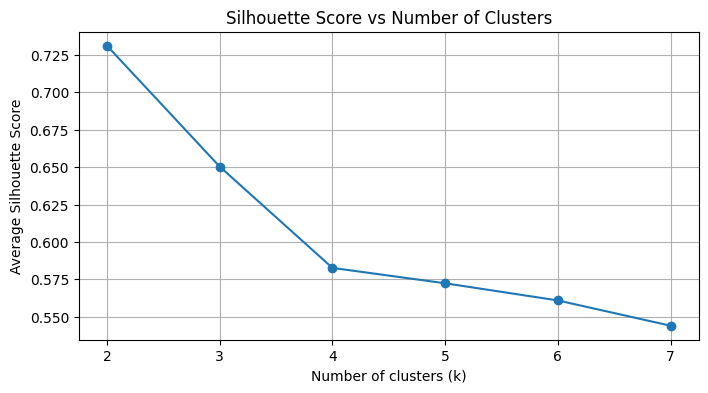

In [9]:
import matplotlib.pyplot as plt
avg_scores = results_df.groupby("k")["silhouette"].mean()

plt.figure(figsize=(8,4))
avg_scores.plot(marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid()
plt.show()

In [10]:
import joblib
joblib.dump(best_kmeans, "../artifacts/kmeans_model.pkl")

['../artifacts/kmeans_model.pkl']

In [12]:
import json
model_config = {
    "model_type": "KMeans",
    "n_clusters": 4,
    "features": [
        "Recency",
        "Frequency",
        "Monetary_log",
        "AvgOrderValue_log"
    ],
    "preprocessing": [
        "log1p on Monetary & AvgOrderValue"
    ],
    "silhouette_score": float(final_score)
}

with open("../artifacts/model_config.json", "w") as f:
    json.dump(model_config, f, indent=4)